https://www.kaggle.com/datasets/mujtabamatin/dataset-for-machine-failure-detection

The dataset consists of the following features:

Temperature (°C): Continuous data representing the temperature at the machine's critical points. Higher temperatures may indicate potential issues due to overheating.
Vibration (Hz): Frequency of machine vibrations. Abnormal vibrations can signal mechanical misalignment, imbalance, or wear.
Power Usage (kW): Power consumption levels of the machine. Spikes in power usage may indicate increased load or potential mechanical issues.
Humidity (%): Environmental humidity around the machine. High humidity levels could affect machine performance and lead to failure over time.
Machine Type: Categorical data indicating the type of machine (e.g., "Drill", "Lathe", "Mill"). Different machine types may have unique failure patterns.
Target Variable:

Failure Risk: A binary label where 0 indicates normal operation, and 1 indicates that the machine is at risk of failure.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [6]:
df = pd.read_csv('datasets/EquipmentFailure/machine_failure_dataset.csv')

In [7]:
df.head()

,Temperature,Vibration,Power_Usage,Humidity,Machine_Type,Failure_Risk
0,74.967142,56.996777,8.649643,20.460962,Mill,1
1,68.617357,54.623168,9.710963,25.698075,Lathe,0
2,76.476885,50.298152,8.415160,27.931972,Drill,1
3,85.230299,46.765316,9.384077,39.438438,Lathe,1
4,67.658466,53.491117,6.212771,32.782766,Drill,1


In [15]:
print(f"Machine Failure Classification using sensor data:")
print(f"--------------------------------")
print(f"Shape: {df.shape}\n")
print(f"Columns: {df.columns}\n")
print(f"Count: {df['Failure_Risk'].value_counts()}\n")
print(f"Products: {df['Machine_Type'].unique()}\n")
print(f"Unique per column: {df.nunique()}\n")
print(f"Max-Min values")
print(f"Temperature: max: {df.Temperature.max()}, min: {df.Temperature.min()}")
print(f"Vibration: max: {df.Vibration.max()}, min: {df.Vibration.min()}")
print(f"Power Usage: max: {df.Power_Usage.max()}, min: {df.Power_Usage.min()}")
print(f"Humidity: max: {df.Humidity.max()}, min: {df.Humidity.min()}\n")

df_error = df[df['Failure_Risk'] == 1]
print(f"Max-Min values where there is an error")
print(f"Temperature: max: {df_error.Temperature.max()}, min: {df_error.Temperature.min()}")
print(f"Vibration: max: {df_error.Vibration.max()}, min: {df_error.Vibration.min()}")
print(f"Power Usage: max: {df_error.Power_Usage.max()}, min: {df_error.Power_Usage.min()}")
print(f"Humidity: max: {df_error.Humidity.max()}, min: {df_error.Humidity.min()}\n")

print(f"Empty values:\n{df.isna().sum()}")

Machine Failure Classification using sensor data:
--------------------------------
Shape: (1000, 6)

Columns: Index(['Temperature', 'Vibration', 'Power_Usage', 'Humidity', 'Machine_Type',
       'Failure_Risk'],
      dtype='object')

Count: Failure_Risk
0    700
1    300
Name: count, dtype: int64

Products: ['Mill' 'Lathe' 'Drill']

Unique per column: Temperature     1000
Vibration       1000
Power_Usage     1000
Humidity        1000
Machine_Type       3
Failure_Risk       2
dtype: int64

Max-Min values
Temperature: max: 108.5273149, min: 37.5873266
Vibration: max: 65.96553784, min: 35.29805683
Power Usage: max: 17.85247541, min: 3.960975688
Humidity: max: 46.21546485, min: 15.35275655

Max-Min values where there is an error
Temperature: max: 97.20169167, min: 37.5873266
Vibration: max: 65.68874267, min: 35.29805683
Power Usage: max: 15.97051801, min: 4.504990315
Humidity: max: 45.76028367, min: 16.98431456

Empty values:
Temperature     0
Vibration       0
Power_Usage     0
Humidity 

In [12]:
df_lathe = df[df['Machine_Type'] == 'Lathe']
df_drill = df[df['Machine_Type'] == 'Drill']
df_other = df[df['Machine_Type'] == 'Other']

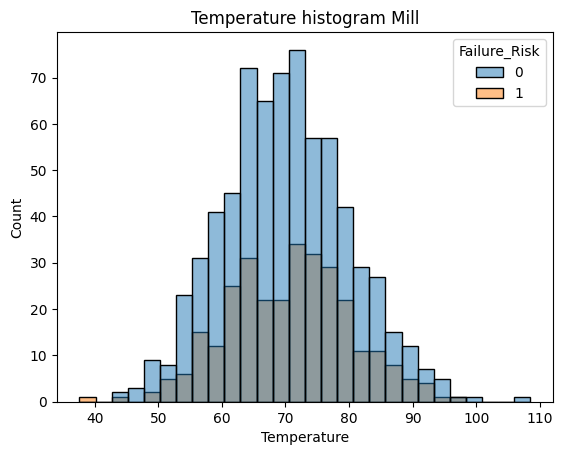

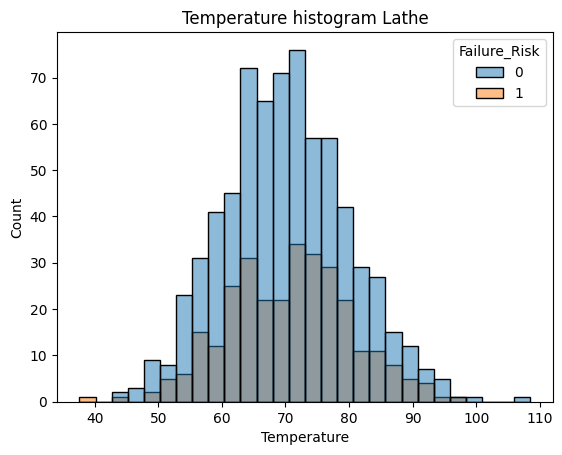

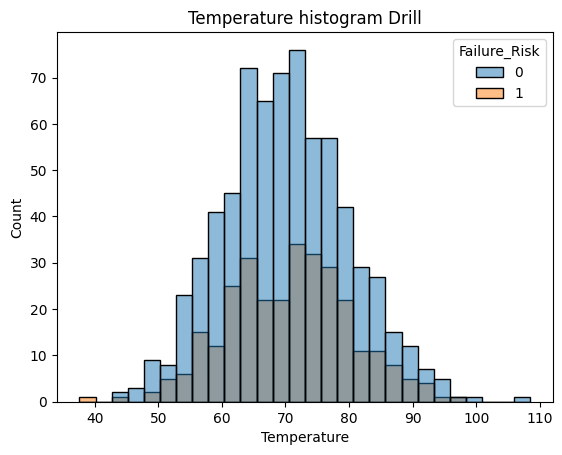

In [22]:
for machine in df['Machine_Type'].unique():
    ax = sns.histplot(df, x='Temperature', hue='Failure_Risk')
    ax.set(title=f'Temperature histogram {machine}')
    plt.show()

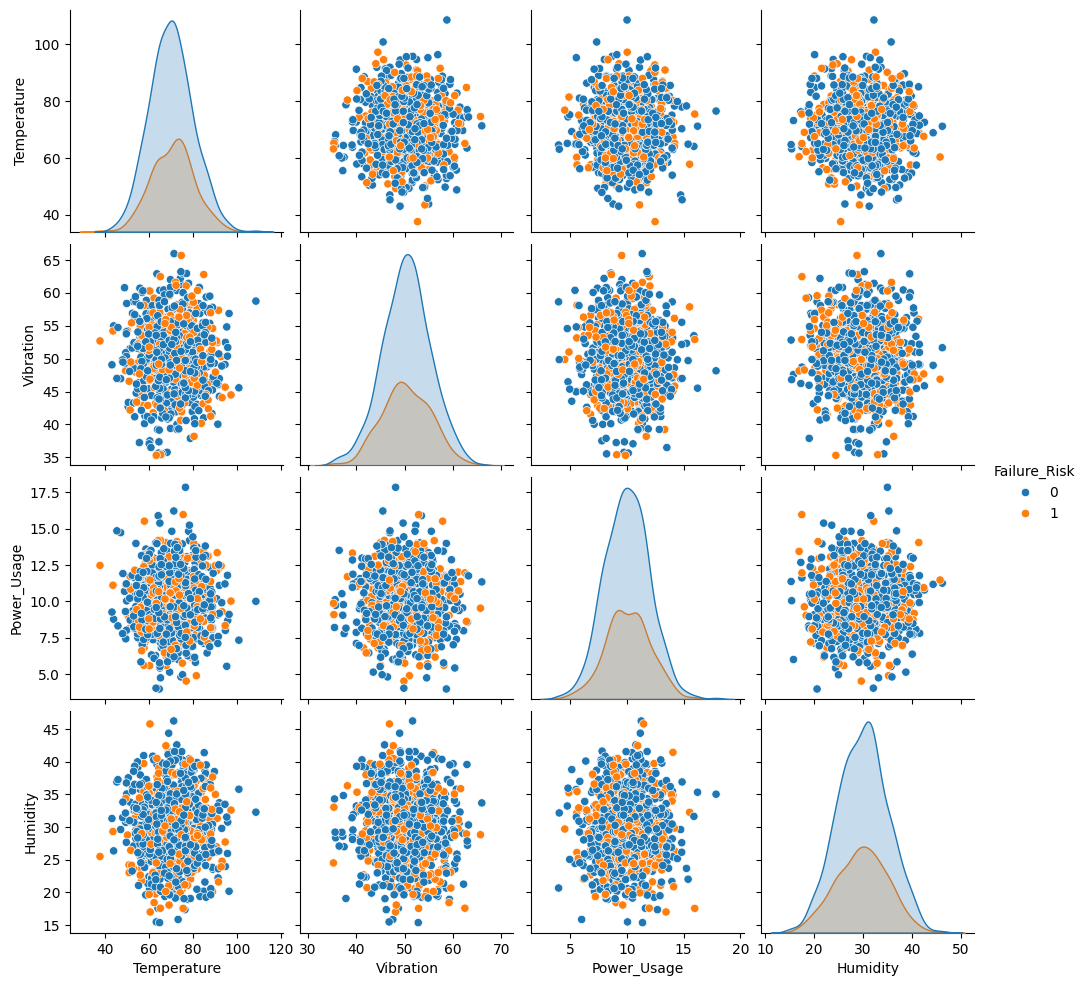

In [17]:
sns.pairplot(df, hue='Failure_Risk')
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()
sns.lineplot(x=df['UDI'], y=df_AI4I['Rotational speed [rpm]'], ax=ax2, label='Rotational Speed [rpm]', color='purple')